In [1]:
import torch
import cv2

In [2]:
from torch.utils.data import Dataset
import numpy as np
import os

# creating Data pipeline 

In [3]:
class WaldoDetectorDataset(Dataset):
    def __init__(self, image_dir, label_dir, img_size=(256, 256)):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.img_size = img_size
        self.image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, image_name)
        label_path = os.path.join(self.label_dir, image_name.replace('.jpg', '.txt'))

        img = cv2.imread(img_path)
        img = cv2.resize(img, self.img_size)
        img = img / 255.0
        img = torch.tensor(img).permute(2, 0, 1).float()

        # Load YOLO label
        with open(label_path, 'r') as f:
            line = f.readline().strip().split()
            _, x_center, y_center, w, h = map(float, line)

        box = torch.tensor([x_center, y_center, w, h], dtype=torch.float32)  # Normalized
        label = torch.tensor([1.0])  # Waldo is class 1

        return img, box, label


In [4]:
dataset = WaldoDetectorDataset(r"C:\works\find_waldo\waldo-5\train\images",r"C:\works\find_waldo\waldo-5\train\labels")

In [5]:
import torch.nn as nn
import torch

class WaldoDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.regressor = nn.Linear(64, 4)  # Bounding box
        self.classifier = nn.Linear(64, 1)  # Waldo confidence

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        bbox = self.regressor(x)
        cls = torch.sigmoid(self.classifier(x))
        return bbox, cls


In [6]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [7]:
import torch.nn as nn

model = WaldoDetector()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

bbox_loss_fn = nn.MSELoss()
class_loss_fn = nn.BCELoss()

for epoch in range(20):
    for img, box, label in dataloader:
        pred_box, pred_cls = model(img)
        loss_box = bbox_loss_fn(pred_box, box)
        loss_cls = class_loss_fn(pred_cls, label)
        loss = loss_box + loss_cls

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")


Epoch 1 Loss: 0.1188
Epoch 2 Loss: 0.0234
Epoch 3 Loss: 0.0126
Epoch 4 Loss: 0.0065
Epoch 5 Loss: 0.0226
Epoch 6 Loss: 0.0198
Epoch 7 Loss: 0.0135
Epoch 8 Loss: 0.0080
Epoch 9 Loss: 0.0074
Epoch 10 Loss: 0.0253
Epoch 11 Loss: 0.0079
Epoch 12 Loss: 0.0140
Epoch 13 Loss: 0.0139
Epoch 14 Loss: 0.0698
Epoch 15 Loss: 0.0212
Epoch 16 Loss: 0.0244
Epoch 17 Loss: 0.0282
Epoch 18 Loss: 0.0531
Epoch 19 Loss: 0.0152
Epoch 20 Loss: 0.0188


In [8]:
# Save
torch.save(model.state_dict(), "waldo_detector.pth")

In [9]:
# Load
model.load_state_dict(torch.load("waldo_detector.pth"))
model.eval()

C:\Users\arfit\AppData\Local\Temp\ipykernel_2940\1940148611.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("waldo_detector.pth"))


WaldoDetector(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (regressor): Linear(in_features=64, out_features=4, bias=True)
  (classifier): Linear(in_features=64, out_features=1, bias=True)
)

In [26]:
def preprocess_image_and_label(image_path, label_path, img_size=(256, 256)):
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError(f"Image not found or failed to load: {image_path}")

    img = cv2.resize(img, img_size)
    img_norm = img / 255.0
    img_tensor = torch.tensor(img_norm).permute(2, 0, 1).float()

    with open(label_path, 'r') as f:
        line = f.readline().strip().split()
        class_id, x_center, y_center, w, h = map(float, line)

    box_tensor = torch.tensor([x_center, y_center, w, h], dtype=torch.float32)
    label_tensor = torch.tensor([class_id], dtype=torch.float32)

    return img_tensor, box_tensor, label_tensor, img


In [11]:
import matplotlib.pyplot as plt

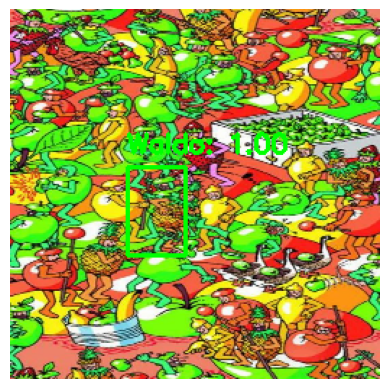

Image saved using Pillow!


In [41]:
from PIL import Image
with torch.no_grad():
    for i in range(1):
        image_path = f"C:/works/find_waldo/waldo-5/test/images/28_jpg.rf.4486cfbb25ca1a6e18f524e972f6cc20.jpg"
        label_path = f"C:/works/find_waldo/waldo-5/test/labels/28_jpg.rf.4486cfbb25ca1a6e18f524e972f6cc20.txt"

        input_tensor, true_box, label, original_img = preprocess_image_and_label(image_path, label_path)

        pred_box, pred_cls = model(input_tensor.unsqueeze(0))  # [1, 4], [1, 1]

        # Convert predicted box from normalized to pixel coordinates
        x, y, w, h = pred_box[0] * 256  # because resized to 256x256
        x1 = int((x - w / 2))
        y1 = int((y - h / 2))
        x2 = int((x + w / 2))
        y2 = int((y + h / 2))

        # Draw predicted box
        cv2.rectangle(original_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(original_img, f"Waldo: {pred_cls.item():.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')  # Turn off axis numbers and ticks
        plt.show()

        image_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        image_pil = Image.fromarray(image_rgb)

        # Save the image using Pillow
        image_pil.save(r"C:\works\find_waldo\result.png")

        print("Image saved using Pillow!")
        # output_path = "C:\works\find_waldo\result.png"  # Define the path and filename

        # # Save the image
        # cv2.imwrite(output_path, original_img)

